In [1]:
!pip install scikit-learn xgboost pandas numpy matplotlib seaborn joblib -q
print("✅ Libraries installed!")


✅ Libraries installed!


In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 1000  # 1000 fake projects

data = {
    "project_type": np.random.choice(
        ["highway", "dam", "school", "hospital", "railway"], n
    ),
    "budget_crore": np.random.randint(10, 2000, n),
    "planned_duration_months": np.random.randint(6, 60, n),
    "contractor_rating": np.random.uniform(1.0, 5.0, n).round(1),
    "state": np.random.choice(
        ["UP", "MP", "Bihar", "Gujarat", "Maharashtra", "Rajasthan"], n
    ),
    "current_progress_pct": np.random.randint(0, 100, n),
    "weather_risk": np.random.choice(["low", "medium", "high"], n),
    "supply_chain_delays": np.random.randint(0, 30, n),  # days
    "num_past_delays": np.random.randint(0, 5, n),
}

df = pd.DataFrame(data)

# 🎯 Target Variable: risk_score (0-100)
# Logic: budget + bad contractor + past delays + weather = high risk
df["risk_score"] = (
    (df["budget_crore"] / 2000 * 20)                       # budget weight
    + ((5 - df["contractor_rating"]) / 4 * 30)             # contractor
    + (df["num_past_delays"] / 5 * 25)                     # past delays
    + (df["supply_chain_delays"] / 30 * 15)                # supply chain
    + (df["weather_risk"].map({"low": 0, "medium": 5, "high": 10}))  # weather
    + np.random.normal(0, 3, n)                            # noise
).clip(0, 100).round(1)

# Risk label
df["risk_label"] = pd.cut(
    df["risk_score"],
    bins=[0, 35, 65, 100],
    labels=["Low", "Medium", "High"]
)

# Delay in days target
df["predicted_delay_days"] = (
    df["supply_chain_delays"] * 2
    + df["num_past_delays"] * 15
    + (df["weather_risk"].map({"low": 0, "medium": 10, "high": 25}))
    + np.random.randint(0, 20, n)
).clip(0, 365)

print(df.head())
print(f"\n✅ Dataset ready: {df.shape}")
print(df["risk_label"].value_counts())


  project_type  budget_crore  planned_duration_months  contractor_rating  \
0     hospital          1493                        8                2.4   
1      railway          1013                       46                4.1   
2       school           365                       47                3.2   
3      railway          1017                       19                1.0   
4      railway          1357                       16                4.0   

         state  current_progress_pct weather_risk  supply_chain_delays  \
0  Maharashtra                    84       medium                   28   
1  Maharashtra                    81       medium                   13   
2    Rajasthan                    76          low                   19   
3  Maharashtra                    79       medium                    5   
4    Rajasthan                    72          low                    6   

   num_past_delays  risk_score risk_label  predicted_delay_days  
0                1        53.1  

In [3]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

df_model = df.copy()

# Encode categorical columns
le = LabelEncoder()
cat_cols = ["project_type", "state", "weather_risk"]
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

# Features
FEATURES = [
    "project_type", "budget_crore", "planned_duration_months",
    "contractor_rating", "state", "current_progress_pct",
    "weather_risk", "supply_chain_delays", "num_past_delays"
]

X = df_model[FEATURES]
y_risk = df_model["risk_score"]          # regression
y_label = df_model["risk_label"]         # classification
y_delay = df_model["predicted_delay_days"]  # regression

# Train/Test split
X_train, X_test, y_risk_train, y_risk_test = train_test_split(
    X, y_risk, test_size=0.2, random_state=42
)
_, _, y_label_train, y_label_test = train_test_split(
    X, y_label, test_size=0.2, random_state=42
)
_, _, y_delay_train, y_delay_test = train_test_split(
    X, y_delay, test_size=0.2, random_state=42
)

print(f"✅ Train: {X_train.shape}, Test: {X_test.shape}")


✅ Train: (800, 9), Test: (200, 9)


In [4]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

risk_model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    verbosity=0
)
risk_model.fit(X_train, y_risk_train)

y_pred = risk_model.predict(X_test)
mae = mean_absolute_error(y_risk_test, y_pred)
r2 = r2_score(y_risk_test, y_pred)

print(f"✅ Risk Score Model:")
print(f"   MAE  = {mae:.2f} (lower is better)")
print(f"   R²   = {r2:.3f} (closer to 1 = better)")


✅ Risk Score Model:
   MAE  = 3.05 (lower is better)
   R²   = 0.914 (closer to 1 = better)


In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

label_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)
label_model.fit(X_train, y_label_train)

y_label_pred = label_model.predict(X_test)
acc = accuracy_score(y_label_test, y_label_pred)

print(f"✅ Risk Label Classifier:")
print(f"   Accuracy = {acc * 100:.1f}%")
print(classification_report(y_label_test, y_label_pred))


✅ Risk Label Classifier:
   Accuracy = 84.5%
              precision    recall  f1-score   support

        High       0.80      0.27      0.40        15
         Low       1.00      0.56      0.72        43
      Medium       0.82      0.99      0.90       142

    accuracy                           0.84       200
   macro avg       0.87      0.61      0.67       200
weighted avg       0.86      0.84      0.82       200



In [6]:
from sklearn.ensemble import GradientBoostingRegressor

delay_model = GradientBoostingRegressor(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)
delay_model.fit(X_train, y_delay_train)

y_delay_pred = delay_model.predict(X_test)
delay_mae = mean_absolute_error(y_delay_test, y_delay_pred)
delay_r2 = r2_score(y_delay_test, y_delay_pred)

print(f"✅ Delay Predictor:")
print(f"   MAE = {delay_mae:.1f} days")
print(f"   R²  = {delay_r2:.3f}")


✅ Delay Predictor:
   MAE = 5.9 days
   R²  = 0.943


/tmp/ipykernel_919/230097171.py:13: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_919/230097171.py:14: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig("feature_importance.png", dpi=150)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


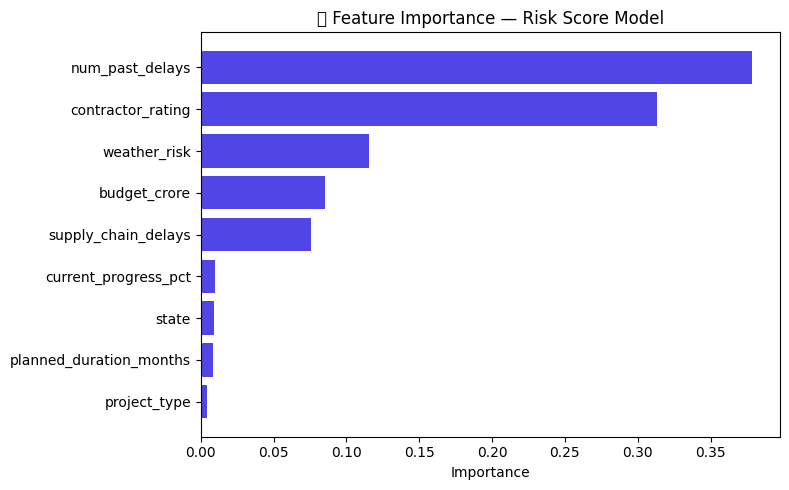

✅ Plot saved!


In [7]:
import matplotlib.pyplot as plt

importances = risk_model.feature_importances_
feat_df = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": importances
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feat_df["Feature"], feat_df["Importance"], color="#4f46e5")
plt.title("📊 Feature Importance — Risk Score Model")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()
print("✅ Plot saved!")


In [8]:
import joblib
import os

os.makedirs("paimana_models", exist_ok=True)

joblib.dump(risk_model,  "paimana_models/risk_score_model.pkl")
joblib.dump(label_model, "paimana_models/risk_label_model.pkl")
joblib.dump(delay_model, "paimana_models/delay_model.pkl")

# Save feature config
import json
config = {
    "features": FEATURES,
    "project_types": ["highway", "dam", "school", "hospital", "railway"],
    "states": ["UP", "MP", "Bihar", "Gujarat", "Maharashtra", "Rajasthan"],
    "weather_risks": ["low", "medium", "high"]
}
with open("paimana_models/config.json", "w") as f:
    json.dump(config, f, indent=2)

print("✅ Models saved!")


✅ Models saved!


In [9]:
from google.colab import drive
drive.mount("/content/drive")

import shutil
shutil.copytree(
    "paimana_models",
    "/content/drive/MyDrive/paimana_models",
    dirs_exist_ok=True
)
print("✅ Models uploaded to Google Drive!")


Mounted at /content/drive
✅ Models uploaded to Google Drive!


In [10]:
def predict_project(project_data: dict):
    """
    project_data example:
    {
        "project_type": "highway",
        "budget_crore": 500,
        "planned_duration_months": 24,
        "contractor_rating": 3.2,
        "state": "UP",
        "current_progress_pct": 35,
        "weather_risk": "high",
        "supply_chain_delays": 15,
        "num_past_delays": 2
    }
    """
    type_map = {"highway": 0, "dam": 1, "school": 2, "hospital": 3, "railway": 4}
    state_map = {"UP": 5, "MP": 2, "Bihar": 0, "Gujarat": 1, "Maharashtra": 3, "Rajasthan": 4}
    weather_map = {"low": 1, "medium": 2, "high": 0}

    row = [[
        type_map.get(project_data["project_type"], 0),
        project_data["budget_crore"],
        project_data["planned_duration_months"],
        project_data["contractor_rating"],
        state_map.get(project_data["state"], 0),
        project_data["current_progress_pct"],
        weather_map.get(project_data["weather_risk"], 1),
        project_data["supply_chain_delays"],
        project_data["num_past_delays"],
    ]]

    risk_score = risk_model.predict(row)[0]
    risk_label = label_model.predict(row)[0]
    delay_days = delay_model.predict(row)[0]

    return {
        "risk_score": round(float(risk_score), 1),
        "risk_label": str(risk_label),
        "predicted_delay_days": int(delay_days)
    }

# 🧪 Test
test_project = {
    "project_type": "highway",
    "budget_crore": 800,
    "planned_duration_months": 36,
    "contractor_rating": 2.5,
    "state": "Bihar",
    "current_progress_pct": 20,
    "weather_risk": "high",
    "supply_chain_delays": 20,
    "num_past_delays": 3
}

result = predict_project(test_project)
print("🎯 Prediction Result:")
print(f"   Risk Score : {result['risk_score']}/100")
print(f"   Risk Label : {result['risk_label']}")
print(f"   Delay      : {result['predicted_delay_days']} days")


🎯 Prediction Result:
   Risk Score : 57.1/100
   Risk Label : Medium
   Delay      : 119 days


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


In [1]:
import joblib, os
joblib.dump(delay_model, "delay_model.pkl")

# Drive pe save karo ya direct download karo
from google.colab import files
files.download("delay_model.pkl")


ModuleNotFoundError: No module named 'joblib'